In [9]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

import torchvision
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix

print("Bibliotecas importadas com sucesso!")
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Bibliotecas importadas com sucesso!
PyTorch: 2.12.1+cpu
TorchVision: 0.27.1+cpu
Dispositivo: cpu


In [10]:
data_dir = "data"

data_transforms = {

    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.1
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225]
        )
    ]),

    "validation": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225]
        )
    ]),

    "test": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225]
        )
    ])
}

image_datasets = {

    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x]
    )

    for x in ["train","validation","test"]

}

dataloaders = {

    x: torch.utils.data.DataLoader(
        image_datasets[x],
        batch_size=4,
        shuffle=True,
        num_workers=4
    )

    for x in ["train","validation","test"]

}

dataset_sizes = {

    x: len(image_datasets[x])

    for x in ["train","validation","test"]

}

class_names = image_datasets["train"].classes

print(class_names)
print(dataset_sizes)

['cat', 'dog']
{'train': 300, 'validation': 100, 'test': 100}


In [11]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):

        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-"*20)

        for phase in ["train","validation"]:

            if phase=="train":
                model.train()

            else:
                model.eval()

            running_loss=0.0
            running_corrects=0

            for inputs,labels in dataloaders[phase]:

                inputs=inputs.to(device)
                labels=labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):

                    outputs=model(inputs)

                    _,preds=torch.max(outputs,1)

                    loss=criterion(outputs,labels)

                    if phase=="train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()*inputs.size(0)

                running_corrects += torch.sum(preds==labels)

            if phase=="train":
                scheduler.step()

            epoch_loss=running_loss/dataset_sizes[phase]

            epoch_acc=running_corrects.double()/dataset_sizes[phase]

            print(f"{phase} Loss:{epoch_loss:.4f} Acc:{epoch_acc:.4f}")

            if phase=="validation" and epoch_acc>best_acc:

                best_acc=epoch_acc

                best_model_wts=copy.deepcopy(model.state_dict())

        print()

    time_elapsed=time.time()-since

    print(f"Treinamento: {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")

    print(f"Melhor validação: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)

    return model

In [21]:
print(cm_resnet)
print(cm_mobilenet)

[[49  1]
 [ 2 48]]
[[49  1]
 [ 5 45]]


In [12]:
def matriz_confusao(model):
    
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for inputs, labels in dataloaders["test"]:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,6))

    plt.imshow(cm, cmap="Blues")
    plt.colorbar()

    plt.xticks([0,1], class_names)
    plt.yticks([0,1], class_names)

    # Escreve os valores nas células
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black",
                fontsize=14,
                fontweight="bold"
            )

    plt.xlabel("Classe Predita")
    plt.ylabel("Classe Real")
    plt.title("Matriz de Confusão")

    plt.tight_layout()
    plt.show()

    return cm

In [13]:
# ============================
# RESNET18
# ============================

model_resnet = models.resnet18(weights="IMAGENET1K_V1")

# Congela as camadas convolucionais
for param in model_resnet.parameters():
    param.requires_grad = False

# Substitui a última camada
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))

model_resnet = model_resnet.to(device)

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.SGD(
    model_resnet.fc.parameters(),
    lr=0.001,
    momentum=0.9
)

scheduler_resnet = lr_scheduler.StepLR(
    optimizer_resnet,
    step_size=7,
    gamma=0.1
)

print("Treinando ResNet...")

model_resnet = train_model(
    model_resnet,
    criterion_resnet,
    optimizer_resnet,
    scheduler_resnet,
    num_epochs=10
)

torch.save(
    model_resnet.state_dict(),
    "resnet_transfer_learning.pth"
)

print("ResNet salva.")

Treinando ResNet...
Epoch 1/10
--------------------
train Loss:0.6520 Acc:0.6600
validation Loss:0.1565 Acc:0.9500

Epoch 2/10
--------------------
train Loss:0.5438 Acc:0.7633
validation Loss:0.1165 Acc:0.9500

Epoch 3/10
--------------------
train Loss:0.4258 Acc:0.8267
validation Loss:0.1402 Acc:0.9500

Epoch 4/10
--------------------
train Loss:0.5617 Acc:0.7667
validation Loss:0.1092 Acc:0.9300

Epoch 5/10
--------------------
train Loss:0.4860 Acc:0.7767
validation Loss:0.1261 Acc:0.9500

Epoch 6/10
--------------------
train Loss:0.4711 Acc:0.7800
validation Loss:0.1193 Acc:0.9500

Epoch 7/10
--------------------
train Loss:0.4516 Acc:0.8167
validation Loss:0.1445 Acc:0.9400

Epoch 8/10
--------------------
train Loss:0.4126 Acc:0.8133
validation Loss:0.1097 Acc:0.9700

Epoch 9/10
--------------------
train Loss:0.3475 Acc:0.8400
validation Loss:0.1134 Acc:0.9300

Epoch 10/10
--------------------
train Loss:0.3560 Acc:0.8433
validation Loss:0.1076 Acc:0.9500

Treinamento: 2m 59s

In [14]:
# ============================
# MOBILENET V2
# ============================

model_mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")

for param in model_mobilenet.parameters():
    param.requires_grad = False

num_ftrs = model_mobilenet.classifier[1].in_features

model_mobilenet.classifier[1] = nn.Linear(
    num_ftrs,
    len(class_names)
)

model_mobilenet = model_mobilenet.to(device)

criterion_mobilenet = nn.CrossEntropyLoss()

optimizer_mobilenet = optim.SGD(
    model_mobilenet.classifier[1].parameters(),
    lr=0.001,
    momentum=0.9
)

scheduler_mobilenet = lr_scheduler.StepLR(
    optimizer_mobilenet,
    step_size=7,
    gamma=0.1
)

print("Treinando MobileNet...")

model_mobilenet = train_model(
    model_mobilenet,
    criterion_mobilenet,
    optimizer_mobilenet,
    scheduler_mobilenet,
    num_epochs=10
)

torch.save(
    model_mobilenet.state_dict(),
    "mobilenet_transfer_learning.pth"
)

print("MobileNet salva.")

Treinando MobileNet...
Epoch 1/10
--------------------
train Loss:0.6216 Acc:0.6667
validation Loss:0.2282 Acc:0.9000

Epoch 2/10
--------------------
train Loss:0.4771 Acc:0.7533
validation Loss:0.1611 Acc:0.9400

Epoch 3/10
--------------------
train Loss:0.5744 Acc:0.7267
validation Loss:0.1811 Acc:0.9200

Epoch 4/10
--------------------
train Loss:0.5984 Acc:0.7367
validation Loss:0.1844 Acc:0.9200

Epoch 5/10
--------------------
train Loss:0.4997 Acc:0.7700
validation Loss:0.1797 Acc:0.9400

Epoch 6/10
--------------------
train Loss:0.4724 Acc:0.7867
validation Loss:0.1731 Acc:0.9300

Epoch 7/10
--------------------
train Loss:0.4350 Acc:0.8067
validation Loss:0.2007 Acc:0.9300

Epoch 8/10
--------------------
train Loss:0.3734 Acc:0.8333
validation Loss:0.1660 Acc:0.9200

Epoch 9/10
--------------------
train Loss:0.3718 Acc:0.8400
validation Loss:0.1798 Acc:0.9300

Epoch 10/10
--------------------
train Loss:0.3685 Acc:0.8467
validation Loss:0.1771 Acc:0.9300

Treinamento: 3m 

In [15]:
def evaluate_model(model, criterion):
    
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():

        for inputs, labels in dataloaders["test"]:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)

    epoch_loss = running_loss / dataset_sizes["test"]

    epoch_acc = running_corrects.double() / dataset_sizes["test"]

    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {epoch_acc:.4f}")

    return epoch_acc

In [16]:
def evaluate_model(model, criterion):
    model.eval()  # Define o modelo para o modo de avaliação
    running_loss = 0.0
    running_corrects = 0

    # Desativa o cálculo de gradientes para avaliação
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    total_loss = running_loss / dataset_sizes["test"]
    total_acc = running_corrects.double() / dataset_sizes["test"]

    print(f'Test Loss: {total_loss:.4f} Acc: {total_acc:.4f}')
    return total_acc


Visualizando predições para ResNet...


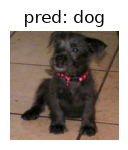

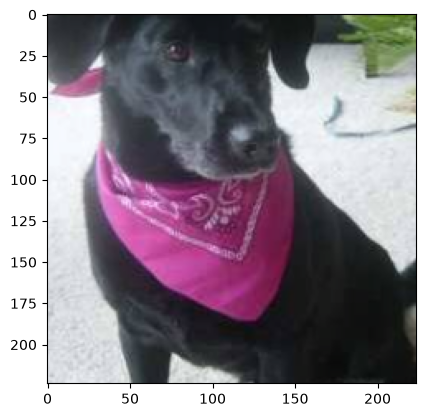

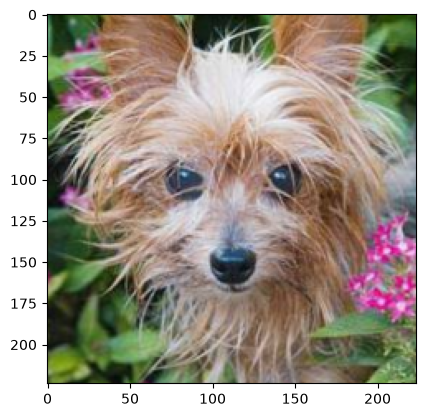

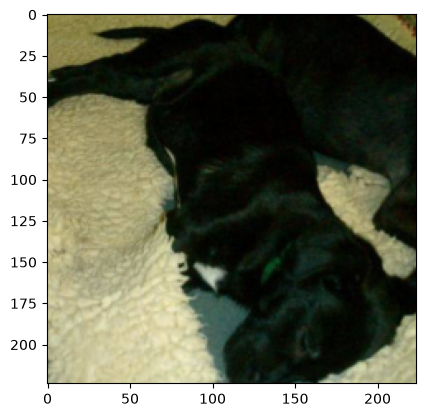

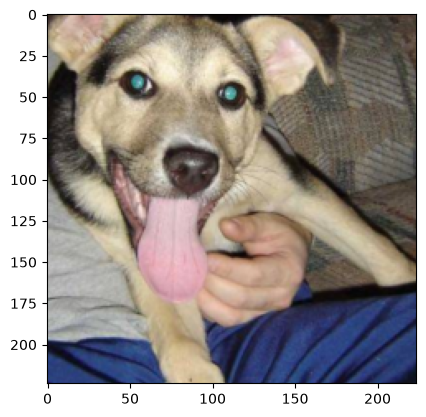

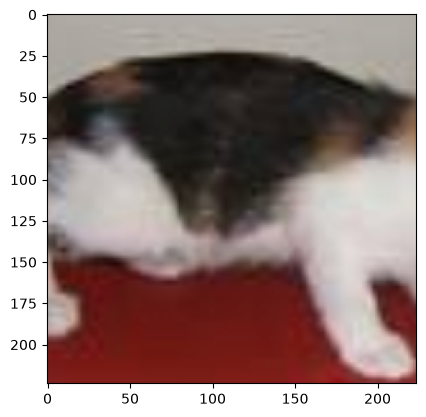


Avaliação do Modelo ResNet no conjunto de teste:
Test Loss: 0.0692 Acc: 0.9700

Matriz de Confusão - ResNet


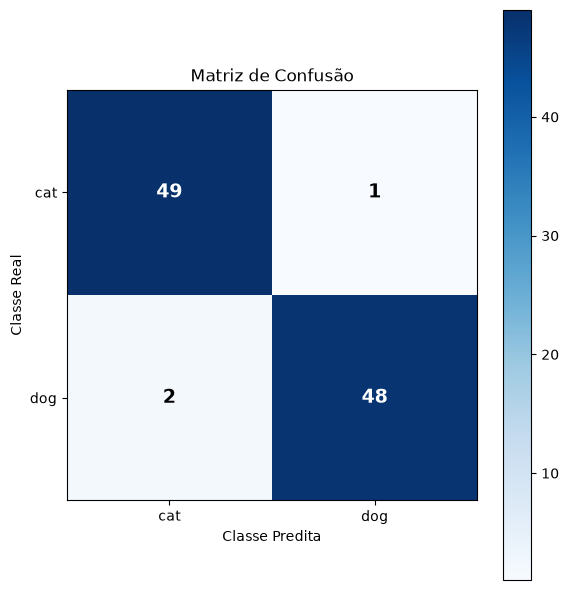


Visualizando predições para MobileNet...


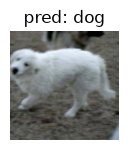

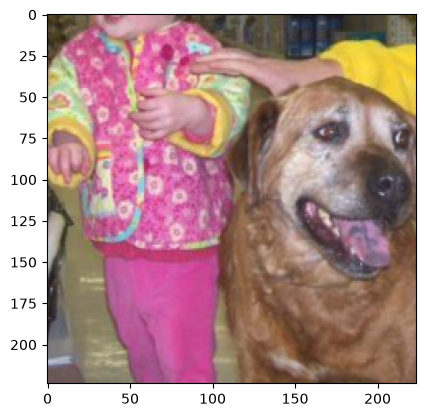

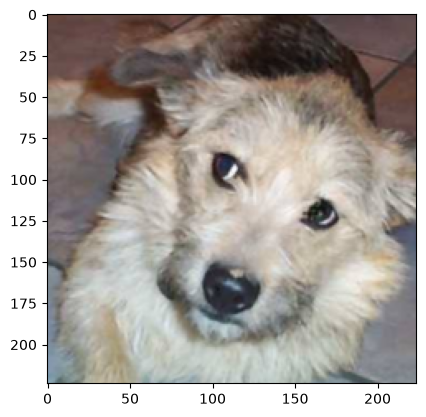

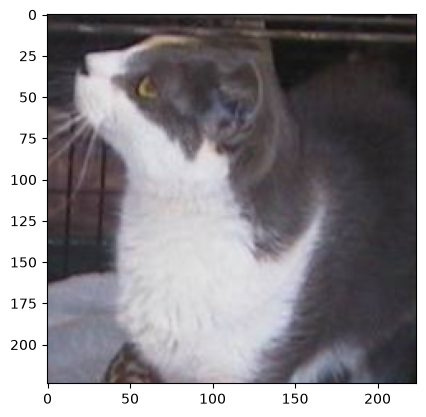

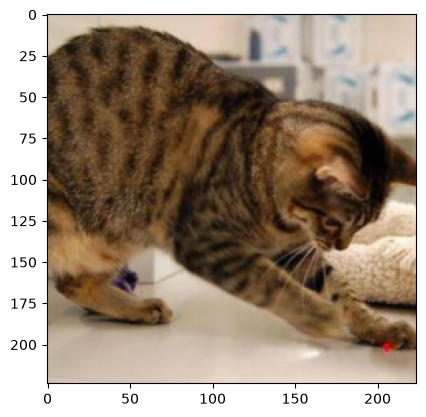

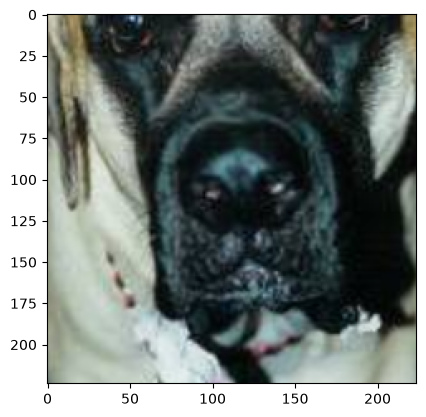


Avaliação do Modelo MobileNet no conjunto de teste:
Test Loss: 0.1701 Acc: 0.9400

Matriz de Confusão - MobileNet


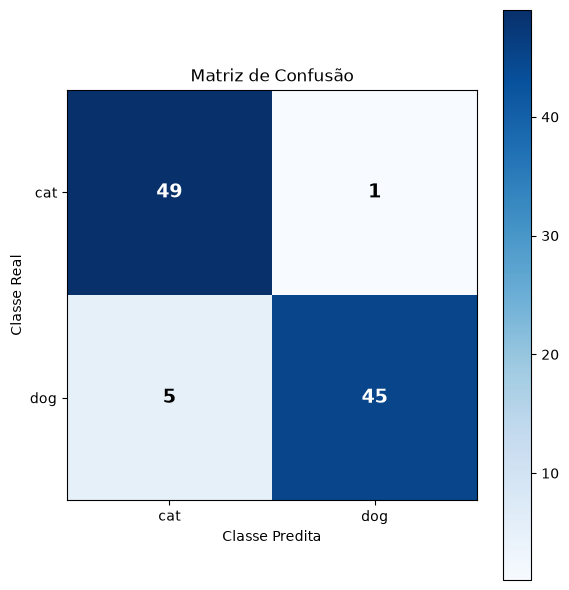

In [17]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders["validation"]):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = fig.add_subplot(num_images//2, 2, images_so_far, xticks=[], yticks=[])
                ax.axis("off")
                ax.set_title(f"pred: {class_names[preds[j]]}")
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


def imshow(inp, title=None):
    """Imshow para Tensores."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


# ==========================
# RESNET
# ==========================

print("\nVisualizando predições para ResNet...")
visualize_model(model_resnet)

print("\nAvaliação do Modelo ResNet no conjunto de teste:")
evaluate_model(model_resnet, criterion_resnet)

print("\nMatriz de Confusão - ResNet")
cm_resnet = matriz_confusao(model_resnet)


# ==========================
# MOBILENET
# ==========================

print("\nVisualizando predições para MobileNet...")
visualize_model(model_mobilenet)

print("\nAvaliação do Modelo MobileNet no conjunto de teste:")
evaluate_model(model_mobilenet, criterion_mobilenet)

print("\nMatriz de Confusão - MobileNet")
cm_mobilenet = matriz_confusao(model_mobilenet)